# Stage 1: Data Preprocessing
**PPG Signal Cleaning & Peak Detection Pipeline**

---

### Mục tiêu
Đọc tín hiệu PPG (Photoplethysmography) thô từ cảm biến MAX30102, loại bỏ nhiễu chuyển động (Motion Artifacts) và nhiễu tần số thấp (Baseline Wander), sau đó phát hiện các đỉnh systolic để tính khoảng R-R Interval phục vụ cho bước Feature Engineering.

### Pipeline
```
Raw CSV --> Motion Filter --> Band`pass Filter --> Peak Detection --> Clean CSV
```

### Thông số kỹ thuật
- Butterworth Bandpass Filter: bậc 4, dải thông [0.7 - 4.0] Hz
- Tần số lấy mẫu: 100 Hz (MAX30102 @ ESP32-C3)
- Phát hiện đỉnh: `scipy.signal.find_peaks` với ràng buộc sinh lý

### Tài liệu tham khảo
- [1] Task Force of ESC/NASPE, "Heart rate variability: Standards of measurement, physiological interpretation and clinical use," *European Heart Journal*, vol. 17, pp. 354-381, 1996.
- [2] Malik et al., "Heart rate variability in relation to prognosis after myocardial infarction," *European Heart Journal*, 1989.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import os
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đồ thị
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# ============================================================
# CẤU HÌNH (Thay đổi tên file ở đây khi đo file mới)
# ============================================================
RAW_FILENAME  = 'PHU_30_PHUT_12-07-2026.csv'
SAMPLING_RATE = 100.0   # Hz - Tần số lấy mẫu của MAX30102
BANDPASS_LOW  = 0.7     # Hz - Tương đương 42 BPM, cắt nhiễu hơi thở
BANDPASS_HIGH = 4.0     # Hz - Tương đương 240 BPM, cắt nhiễu điện từ
FILTER_ORDER  = 4       # Bậc bộ lọc Butterworth
# ============================================================

filepath = f'../data/raw/{RAW_FILENAME}'
df = pd.read_csv(filepath)

duration_min = (df['Time(ms)'].iloc[-1] - df['Time(ms)'].iloc[0]) / 60000

print(f'Đã đọc file: {RAW_FILENAME}')
print(f'  Tổng số dòng: {len(df):,}')
print(f'  Thời lượng ước tính: {duration_min:.1f} phút')

Đã đọc file: PHU_30_PHUT_12-07-2026.csv
  Tổng số dòng: 147,024
  Thời lượng ước tính: 37.5 phút


## 2. Exploratory Data Analysis (Khám phá dữ liệu)

Trước khi xử lý, cần khám phá dữ liệu thô để hiểu cấu trúc và phát hiện các vấn đề tiềm ẩn như giá trị thiếu (NaN), giá trị bất thường (outlier), hoặc lỗi cảm biến.

In [2]:
# Bảng thống kê tổng quan
print('=' * 60)
print('DATA SUMMARY REPORT')
print('=' * 60)
print(f'\nFile: {RAW_FILENAME}')
print(f'Kích thước: {len(df):,} rows x {len(df.columns)} columns')
print(f'Sampling Rate: {SAMPLING_RATE} Hz')
print(f'\nCác cột dữ liệu: {list(df.columns)}')
print(f'\nKiểm tra giá trị thiếu (NaN):')
print(df.isnull().sum().to_string())
print(f'\nThống kê mô tả:')
df.describe().round(2)

DATA SUMMARY REPORT

File: PHU_30_PHUT_12-07-2026.csv
Kích thước: 147,024 rows x 6 columns
Sampling Rate: 100.0 Hz

Các cột dữ liệu: ['Time(ms)', 'IR', 'RED', 'BPM', 'SpO2', 'Motion']

Kiểm tra giá trị thiếu (NaN):
Time(ms)    0
IR          0
RED         0
BPM         0
SpO2        0
Motion      0

Thống kê mô tả:


,Time(ms),IR,RED,BPM,SpO2,Motion
count,147024.00,147024.00,147024.00,147024.00,147024.00,147024.0
mean,1206056.45,190828.45,32277.82,91.21,90.53,0.0
std,655302.16,3073.13,260.53,6.73,6.48,0.0
min,99987.00,82465.00,23947.00,69.00,78.00,0.0
25%,648014.50,188429.00,32243.00,86.00,85.00,0.0
50%,1196063.00,190211.00,32307.00,92.00,92.00,0.0
75%,1804121.50,193762.00,32394.00,96.00,96.00,0.0
max,2352109.00,195814.00,32734.00,127.00,127.00,0.0


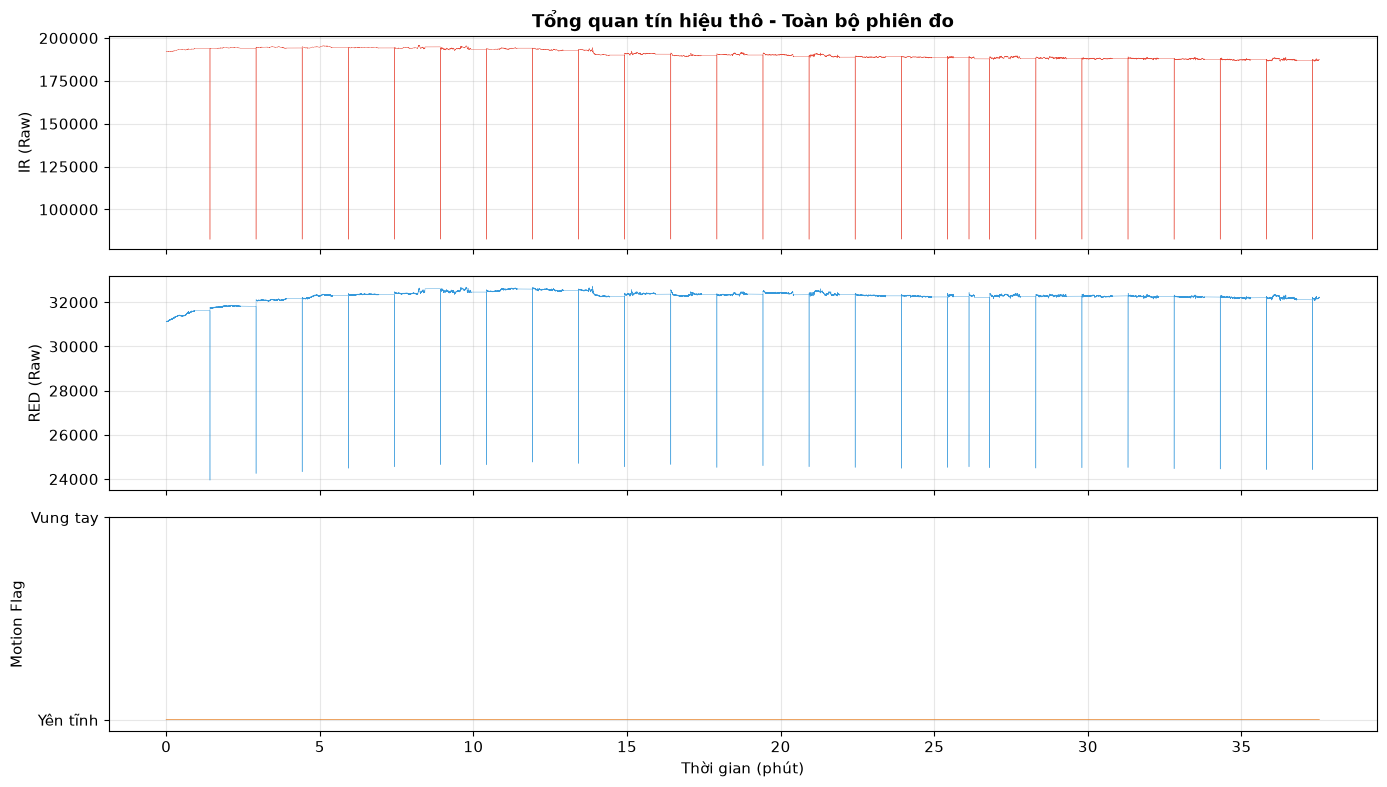

In [3]:
# Vẽ tổng quan toàn bộ tín hiệu thô
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

time_minutes = (df['Time(ms)'] - df['Time(ms)'].iloc[0]) / 60000

axes[0].plot(time_minutes, df['IR'], color='#e74c3c', linewidth=0.3)
axes[0].set_ylabel('IR (Raw)')
axes[0].set_title('Tổng quan tín hiệu thô - Toàn bộ phiên đo', fontweight='bold', fontsize=13)

axes[1].plot(time_minutes, df['RED'], color='#3498db', linewidth=0.3)
axes[1].set_ylabel('RED (Raw)')

axes[2].plot(time_minutes, df['Motion'], color='#e67e22', linewidth=0.5)
axes[2].set_ylabel('Motion Flag')
axes[2].set_xlabel('Thời gian (phút)')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Yên tĩnh', 'Vung tay'])

plt.tight_layout()
plt.show()

## 3. Motion Artifact Removal (Loại bỏ nhiễu chuyển động)

Cảm biến gia tốc MPU6050 được sử dụng để phát hiện chuyển động cánh tay. Những mẫu dữ liệu có cờ `Motion = 1` sẽ bị loại bỏ hoàn toàn vì tín hiệu PPG trong khoảng thời gian này bị nhiễu nặng do hiện tượng **Motion Artifact** (MA).

Đây là bước lọc đầu tiên và đơn giản nhất: chỉ giữ lại những dòng dữ liệu mà người đo ngồi/nằm yên (Motion = 0).

In [4]:
n_motion = len(df[df['Motion'] == 1])
n_clean = len(df[df['Motion'] == 0])

print(f'Số mẫu bị nhiễu chuyển động (Motion=1): {n_motion:,} ({n_motion/len(df)*100:.1f}%)')
print(f'Số mẫu sạch (Motion=0):                 {n_clean:,} ({n_clean/len(df)*100:.1f}%)')

# Chỉ giữ lại mẫu sạch
df_clean = df[df['Motion'] == 0].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f'\nĐã loại bỏ {n_motion:,} mẫu nhiễu. Còn lại {len(df_clean):,} mẫu sạch.')

Số mẫu bị nhiễu chuyển động (Motion=1): 0 (0.0%)
Số mẫu sạch (Motion=0):                 147,024 (100.0%)

Đã loại bỏ 0 mẫu nhiễu. Còn lại 147,024 mẫu sạch.


## 4. Bandpass Filtering (Lọc thông dải Butterworth)

Tín hiệu PPG thô từ cảm biến MAX30102 bị ảnh hưởng bởi nhiều yếu tố:

- **Baseline Wander** (trôi đường nền): Do nhịp thở của người đo làm thay đổi áp lực máu, tạo ra một sóng chậm có tần số khoảng 0.15-0.4 Hz phủ lên tín hiệu nhịp tim.
- **Nhiễu cao tần**: Do nhiễu điện từ từ môi trường (đèn, màn hình, dây dẫn) có tần số 50Hz trở lên.

Bộ lọc **Butterworth Bandpass Filter** bậc 4 sẽ chỉ cho phép đi qua những tín hiệu có tần số nằm trong khoảng [0.7 - 4.0] Hz, tương đương với nhịp tim từ 42 đến 240 BPM. Mọi thứ ngoài dải này sẽ bị loại bỏ [1].

Trước khi lọc, tín hiệu được **zero-centered** (trừ đi giá trị trung bình) để tránh hiệu ứng transient response của bộ lọc.

In [5]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Áp dụng bộ lọc Butterworth Bandpass Filter.
    
    Parameters:
        data: Tín hiệu đầu vào
        lowcut: Tần số cắt dưới (Hz)
        highcut: Tần số cắt trên (Hz)
        fs: Tần số lấy mẫu (Hz)
        order: Bậc bộ lọc
    Returns:
        Tín hiệu đã lọc
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# Zero-centering: Trừ đi giá trị trung bình để kéo tín hiệu về quanh mốc 0
ir_centered = df_clean['IR'] - df_clean['IR'].mean()

# Áp dụng Bandpass Filter
df_clean['IR_Filtered'] = butter_bandpass_filter(ir_centered, BANDPASS_LOW, BANDPASS_HIGH, SAMPLING_RATE, FILTER_ORDER)

print(f'Đã áp dụng Butterworth Bandpass Filter [{BANDPASS_LOW} - {BANDPASS_HIGH}] Hz, bậc {FILTER_ORDER}')

Đã áp dụng Butterworth Bandpass Filter [0.7 - 4.0] Hz, bậc 4


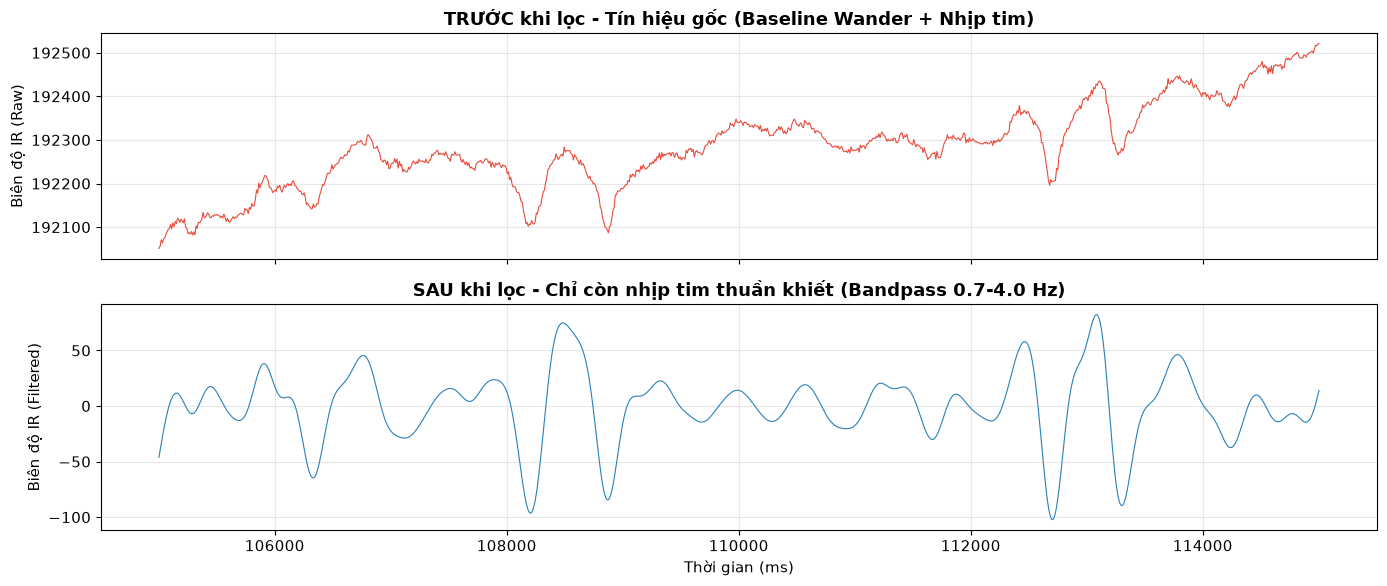

In [6]:
# Biểu đồ so sánh TRƯỚC vs SAU khi lọc (10 giây)
start_idx = 500
end_idx = 1500
time_slice = df_clean['Time(ms)'].iloc[start_idx:end_idx]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time_slice, df_clean['IR'].iloc[start_idx:end_idx], color='#e74c3c', linewidth=0.8)
axes[0].set_ylabel('Biên độ IR (Raw)')
axes[0].set_title('TRƯỚC khi lọc - Tín hiệu gốc (Baseline Wander + Nhịp tim)', fontweight='bold')

axes[1].plot(time_slice, df_clean['IR_Filtered'].iloc[start_idx:end_idx], color='#2980b9', linewidth=0.8)
axes[1].set_ylabel('Biên độ IR (Filtered)')
axes[1].set_title('SAU khi lọc - Chỉ còn nhịp tim thuần khiết (Bandpass 0.7-4.0 Hz)', fontweight='bold')
axes[1].set_xlabel('Thời gian (ms)')

plt.tight_layout()
plt.show()

## 5. Peak Detection (Phát hiện đỉnh nhịp tim)

Sau khi lọc xong, mỗi đỉnh nhọn hướng lên trên đồ thị chính là một nhịp đập của tim (Systolic Peak). Sử dụng hàm `scipy.signal.find_peaks` để tự động phát hiện các đỉnh này, với các ràng buộc sinh lý:

- **Khoảng cách tối thiểu giữa 2 đỉnh:** 300ms (tương đương nhịp tim tối đa 200 BPM)
- **Prominence tối thiểu:** Loại bỏ các đỉnh giả do nhiễu nhỏ

Khoảng cách thời gian giữa 2 đỉnh liên tiếp gọi là **R-R Interval** (hoặc IBI - Inter-Beat Interval). Đây chính là nguyên liệu chính để tính toán các chỉ số biến thiên nhịp tim (HRV) ở bước tiếp theo.

Các R-R Interval ngoài giới hạn sinh lý (nhỏ hơn 300ms hoặc lớn hơn 2000ms) sẽ bị loại bỏ theo tiêu chí Malik [2].

In [7]:
# Phát hiện đỉnh trên toàn bộ dữ liệu
min_distance = int(0.3 * SAMPLING_RATE)  # 300ms = 30 samples @ 100Hz
peaks, properties = find_peaks(df_clean['IR_Filtered'], distance=min_distance, prominence=10)

# Tính R-R Intervals
peak_times = df_clean['Time(ms)'].iloc[peaks].values
rr_intervals = np.diff(peak_times)

# Lọc bỏ R-R ngoài giới hạn sinh lý (300ms - 2000ms) theo tiêu chí Malik
rr_valid = rr_intervals[(rr_intervals >= 300) & (rr_intervals <= 2000)]

print(f'Tổng số đỉnh nhịp tim phát hiện được: {len(peaks):,}')
print(f'Số R-R Intervals hợp lệ: {len(rr_valid):,} / {len(rr_intervals):,}')
print(f'\nThống kê R-R Interval (ms):')
print(f'  Mean:  {np.mean(rr_valid):.1f} ms  ->  HR = {60000/np.mean(rr_valid):.0f} BPM')
print(f'  Std:   {np.std(rr_valid):.1f} ms')
print(f'  Min:   {np.min(rr_valid):.1f} ms  ->  HR = {60000/np.min(rr_valid):.0f} BPM')
print(f'  Max:   {np.max(rr_valid):.1f} ms  ->  HR = {60000/np.max(rr_valid):.0f} BPM')

Tổng số đỉnh nhịp tim phát hiện được: 2,396
Số R-R Intervals hợp lệ: 2,369 / 2,395

Thống kê R-R Interval (ms):
  Mean:  617.1 ms  ->  HR = 97 BPM
  Std:   173.6 ms
  Min:   300.0 ms  ->  HR = 200 BPM
  Max:   1812.0 ms  ->  HR = 33 BPM


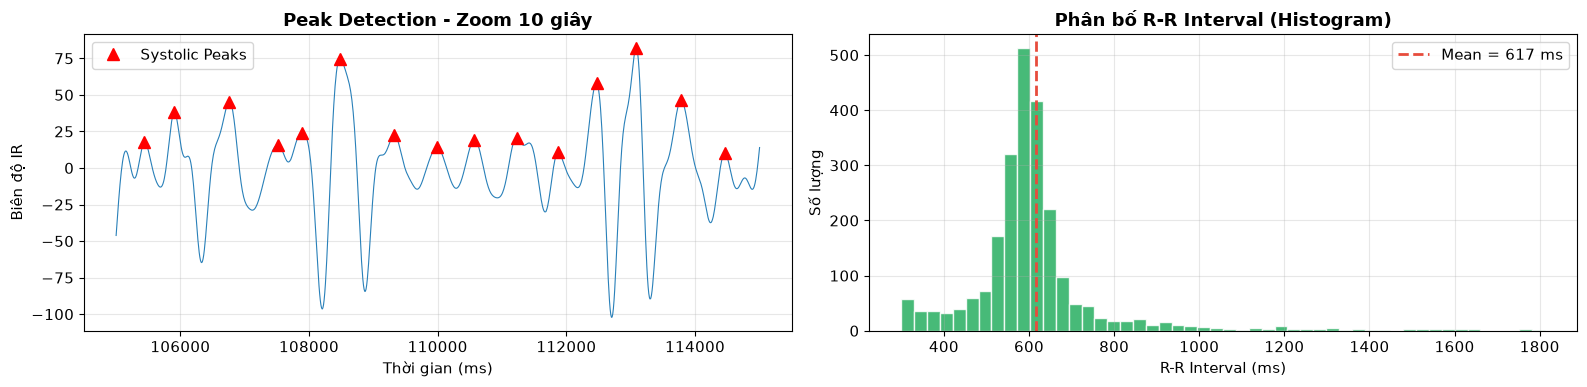

In [8]:
# Biểu đồ: Peak Detection (Zoom 10 giây) + Histogram R-R
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Biểu đồ trái: Zoom vào 10 giây, đánh dấu đỉnh ---
s, e = 500, 1500
peaks_in_range = [p for p in peaks if s <= p < e]

axes[0].plot(df_clean['Time(ms)'].iloc[s:e], df_clean['IR_Filtered'].iloc[s:e], color='#2980b9', linewidth=0.8)
axes[0].plot(df_clean['Time(ms)'].iloc[peaks_in_range], df_clean['IR_Filtered'].iloc[peaks_in_range], 'r^', markersize=8, label='Systolic Peaks')
axes[0].set_title('Peak Detection - Zoom 10 giây', fontweight='bold')
axes[0].set_xlabel('Thời gian (ms)')
axes[0].set_ylabel('Biên độ IR')
axes[0].legend()

# --- Biểu đồ phải: Phân bố R-R Interval ---
axes[1].hist(rr_valid, bins=50, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(rr_valid), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean = {np.mean(rr_valid):.0f} ms')
axes[1].set_title('Phân bố R-R Interval (Histogram)', fontweight='bold')
axes[1].set_xlabel('R-R Interval (ms)')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Export Clean Data

In [9]:
# Lưu dữ liệu sạch
os.makedirs('../data/processed', exist_ok=True)
save_path = '../data/processed/clean_PHU_30_PHUT.csv'
df_clean.to_csv(save_path, index=False)

print('=' * 60)
print('PREPROCESSING HOÀN TẤT')
print('=' * 60)
print(f'Input:  {filepath} ({len(df):,} rows)')
print(f'Output: {save_path} ({len(df_clean):,} rows)')
print(f'Đã loại bỏ: {len(df) - len(df_clean):,} rows (Motion Artifacts)')
print(f'Nhịp tim phát hiện: {len(peaks):,} beats')
print(f'HR trung bình: {60000/np.mean(rr_valid):.0f} BPM')

PREPROCESSING HOÀN TẤT
Input:  ../data/raw/PHU_30_PHUT_12-07-2026.csv (147,024 rows)
Output: ../data/processed/clean_PHU_30_PHUT.csv (147,024 rows)
Đã loại bỏ: 0 rows (Motion Artifacts)
Nhịp tim phát hiện: 2,396 beats
HR trung bình: 97 BPM
